# Loki health -- general status

How Loki is doing right now: component health, request errors/panics, ingest and
stream counts, **end-to-end delivery via loki-canary**, compaction, plus its own
**logs** and **firing alerts** as independent cross-checks. Uses the LGTM stack
normally and assumes it basically works; [loki-nolgtm.ipynb](loki-nolgtm.ipynb) is
the tool for when Loki is unhappy and can't answer about itself. Capacity/tenants:
[loki-usage.ipynb](loki-usage.ipynb).

Loki's own mixin rules are **not deployed** (`monitoring.rules.enabled: false` in
`loki-values.yaml`), so findings thresholds are sourced from the **upstream
loki-mixin** and cited inline; there is no in-cluster Loki alert to read them from.

Design: [tiles#644](https://github.com/symmatree/tiles/issues/644),
[docs/notebooks.md](../docs/notebooks.md), `facts/notebook-analysis/design-intent.md`.

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace loki-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # Loki self-metrics are scraped INTO Mimir
loki_url = "http://loki.loki.svc:3100"        # Loki's own HTTP API (logs); no gateway in SingleBinary
tenant = "tiles"       # X-Scope-OrgID for Mimir and Loki
namespace = "loki"     # namespace scoping for logs, alerts, kube metrics
lookback_hours = 24
range_step_s = 300
log_sample_lines = 100
capture_file = ""      # replay a prior raw capture JSON instead of querying live
output_dir = ""        # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'loki-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url,
                  tenant=tenant, namespace=namespace, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, log_sample_lines=log_sample_lines)
tenant, namespace = cap.meta['tenant'], cap.meta['namespace']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)
lk = nbc.Loki(cap, cap.meta['loki_url'], tenant)
print(f"mimir: {cap.meta['mimir_url']}  loki: {cap.meta['loki_url']}  tenant: {tenant}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  live


In [3]:
# --- ASSUMPTIONS: verify the instruments before trusting any reading ---
# Fatal (whole notebook unassessable): Loki self-monitoring absent/stale -- the
# tiles#556 mode where loki_* is exposed but scraped by nothing, so a dead pipeline
# reads as healthy. Non-fatal: kube_*/cadvisor/canary/Loki-log gaps degrade only
# their own section.
assumption_warnings = []
STALE_S = 600

binfo = mm.q('buildinfo', 'loki_build_info')
loki_version = binfo[0]['metric'].get('version', 'unknown') if binfo else 'unknown'

freshness = {
    'loki self-monitoring': 'max(timestamp(loki_ingester_memory_streams))',
    'loki-canary': 'max(timestamp(loki_canary_entries_total))',
    'kube-state-metrics (loki ns)': f'max(timestamp(kube_pod_info{{namespace="{namespace}"}}))',
    'cadvisor (loki ns)': f'max(timestamp(container_memory_working_set_bytes{{namespace="{namespace}"}}))',
}
inst_age = {}
for inst, query in freshness.items():
    ts = nbc.val(mm.q(f'fresh: {inst}', query))
    inst_age[inst] = cap.now - ts if not np.isnan(ts) else np.inf
try:
    probe = lk.lines('fresh: loki (loki ns logs)', f'{{namespace="{namespace}"}}', 1, 1)
    inst_age['loki (loki ns logs)'] = cap.now - probe[0][0].timestamp() if probe else np.inf
except Exception:
    inst_age['loki (loki ns logs)'] = np.inf

print("=== ASSUMPTIONS ===")
print(f"  loki {loki_version} self-metrics via mimir {cap.meta['mimir_url']}")
for inst, age in inst_age.items():
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > STALE_S else '')
    print(f"  {inst:<32} {status}")

# Fatal iff the load-bearing self-monitoring instrument is dead: everything below
# reads loki_* through Mimir, so if that is stale the whole verdict is untrustworthy.
self_age = inst_age['loki self-monitoring']
if np.isinf(self_age) or self_age > STALE_S:
    raise RuntimeError(f"unassessable: loki self-monitoring stale or absent "
                       f"({self_age:.0f}s) -- fix scraping before trusting this notebook")
for inst, age in inst_age.items():
    if inst != 'loki self-monitoring' and (np.isinf(age) or age > STALE_S):
        assumption_warnings.append(f"{inst} stale/missing ({age:.0f}s) -- its section is degraded")

=== ASSUMPTIONS ===
  loki 3.6.3 self-metrics via mimir http://mimir-gateway.mimir.svc
  loki self-monitoring             newest sample 13s old
  loki-canary                      newest sample 1s old
  kube-state-metrics (loki ns)     newest sample 57s old
  cadvisor (loki ns)               newest sample 18s old
  loki (loki ns logs)              newest sample 4s old


In [4]:
# --- CAPTURE: fetch the complete observation up front, before any analysis,
# so a broken analysis cell cannot cost us the raw snapshot.
up_ok = nbc.by(mm.q('up_ok_by_job', f'sum by (job) (up{{namespace="{namespace}"}})'), 'job')
up_all = nbc.by(mm.q('up_targets_by_job', f'count by (job) (up{{namespace="{namespace}"}})'), 'job')
restarts = nbc.by(mm.q('restarts_by_pod', f'sum by (pod) (kube_pod_container_status_restarts_total{{namespace="{namespace}"}})'), 'pod')
last_term = mm.q('last_terminated_reason', f'kube_pod_container_status_last_terminated_reason{{namespace="{namespace}"}} == 1')
mem_ws = nbc.by(mm.q('mem_working_set_by_pod', f'sum by (pod) (container_memory_working_set_bytes{{namespace="{namespace}", container!=""}})'), 'pod')
mem_lim = nbc.by(mm.q('mem_limit_by_pod', f'sum by (pod) (kube_pod_container_resource_limits{{namespace="{namespace}", resource="memory"}})'), 'pod')
ring_unhealthy = nbc.by(mm.q('ring_members_unhealthy', 'sum by (name) (loki_ring_members{state="Unhealthy"})'), 'name')
compactor_last = nbc.val(mm.q('compactor_last_success', 'max(loki_boltdb_shipper_compact_tables_operation_last_successful_run_timestamp_seconds)'))
compactors_running = nbc.val(mm.q('compactors_running', 'sum(loki_boltdb_shipper_compactor_running)'))
panics = nbc.val(mm.q('panics_window', f'sum(increase(loki_panic_total[{lookback_hours}h]))'), 0.0)
streams_active = nbc.val(mm.q('streams_active', 'sum(loki_ingester_memory_streams)'))

f_errratio = nbc.frame(mm.qr('request_error_ratio_by_route',
    'sum by (route) (rate(loki_request_duration_seconds_count{status_code=~"5.."}[5m]))'
    ' / sum by (route) (rate(loki_request_duration_seconds_count[5m]))',
    lookback_hours, step), 'route')
f_ing_lines = nbc.frame(mm.qr('ingest_lines', 'sum(rate(loki_distributor_lines_received_total[5m]))', lookback_hours, step), None)
f_ing_bytes = nbc.frame(mm.qr('ingest_bytes', 'sum(rate(loki_distributor_bytes_received_total[5m]))', lookback_hours, step), None)
f_discard = nbc.frame(mm.qr('discarded_by_reason', 'sum by (reason) (rate(loki_discarded_samples_total[5m]))', lookback_hours, step), 'reason')

# loki-canary: writes a known line to Loki and reads it back on every node; missing
# or mismatched entries are the sharpest end-to-end "logs are actually flowing" signal.
f_can_entries = nbc.frame(mm.qr('canary_entries', 'sum(rate(loki_canary_entries_total[5m]))', lookback_hours, step), None)
f_can_missing = nbc.frame(mm.qr('canary_missing', 'sum(rate(loki_canary_missing_entries_total[5m]))', lookback_hours, step), None)
canary_missing_total = nbc.val(mm.q('canary_missing_total', f'sum(increase(loki_canary_missing_entries_total[{lookback_hours}h]))'), 0.0)
canary_mismatch_total = nbc.val(mm.q('canary_mismatch_total', f'sum(increase(loki_canary_mismatched_entries_total[{lookback_hours}h]))'), 0.0)
canary_entries_total = nbc.val(mm.q('canary_entries_total_w', f'sum(increase(loki_canary_entries_total[{lookback_hours}h]))'), 0.0)

# Alerts as an independent cross-check (Alertmanager API post-routing vs ALERTS series).
am_rec = mm.get('alertmanager_alerts', '/alertmanager/api/v2/alerts')
am_alerts = am_rec.get('json', []) if 'json' in am_rec else []
alerts_now = mm.q('alerts_firing_now', f'ALERTS{{namespace="{namespace}", alertstate="firing"}}')
alerts_ns_24h = mm.q('alerts_ns_24h', f'sum by (alertname) (count_over_time(ALERTS{{namespace="{namespace}", alertstate="firing"}}[24h]))')

# Logs (Loki's own): level volume, error/warn sample, wide-angle raw tail.
f_loglevel = nbc.frame(lk.metric_range('log_volume_by_level',
    f'sum by (detected_level) (count_over_time({{namespace="{namespace}"}}[10m]))', lookback_hours, 600), 'detected_level')
log_errwarn = lk.lines('log_errwarn_sample', f'{{namespace="{namespace}"}} | detected_level=~"error|warn"', lookback_hours, 50)
log_tail = lk.lines('log_tail_sample', f'{{namespace="{namespace}"}}', lookback_hours, log_sample_lines)
print(f"captured {len(cap.data['calls'])} raw calls")

captured 32 raw calls


all 5 scrape targets up across 2 jobs
                   mem_mb limit_mb  restarts mem_pct               last_term
loki-0                490        -         5       -                   Error
loki-canary-clnfq      53        -         1       -  ContainerStatusUnknown
loki-canary-kvrp7      30        -         0       -                       -
loki-canary-dx65t      27        -         0       -                       -
loki-canary-sgs27      18        -         0       -                       -
unhealthy ring members: none
compactors running: 1 (mixin LokiTooManyCompactorsRunning fires at >1)


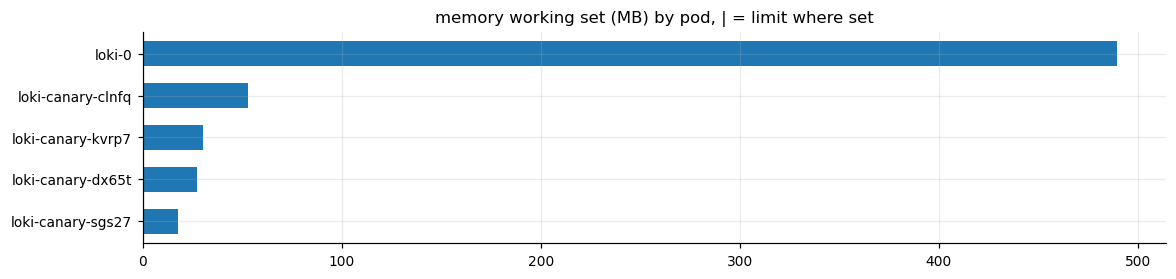

In [5]:
# --- COMPONENT HEALTH: scrape up-ness, restarts, OOMs, memory vs limits, ring ---
scrape = pd.DataFrame({'up': pd.Series(up_ok), 'targets': pd.Series(up_all)})
scrape_down = sorted(scrape[scrape['up'] < scrape['targets']].index)
if scrape_down:
    print(f"scrape targets DOWN: {scrape_down}")
else:
    print(f"all {int(scrape['targets'].sum())} scrape targets up across {len(scrape)} jobs")

pods = pd.DataFrame({'mem_mb': pd.Series(mem_ws) / 2**20,
                     'limit_mb': pd.Series(mem_lim) / 2**20,
                     'restarts': pd.Series(restarts)})
pods['mem_pct'] = 100 * pods['mem_mb'] / pods['limit_mb']
pods['last_term'] = pd.Series({r['metric']['pod']: r['metric']['reason'] for r in last_term})
pods = pods.sort_values('mem_mb', ascending=False)
print(pods.to_string(float_format=lambda v: f'{v:,.0f}', na_rep='-'))

oom_pods = sorted(pods[pods['last_term'] == 'OOMKilled'].index)
restart_pods = {p: int(n) for p, n in pods['restarts'].items() if n > 0}
ring_bad = {k: int(v) for k, v in ring_unhealthy.items() if v > 0}
print(f"unhealthy ring members: {ring_bad or 'none'}")
print(f"compactors running: {compactors_running:.0f} (mixin LokiTooManyCompactorsRunning fires at >1)")

fig, ax = plt.subplots(figsize=(12, 0.3 * len(pods) + 1))
ax.barh(pods.index[::-1], pods['mem_mb'][::-1], color='C0', height=0.6)
lim = pods['limit_mb'].dropna()
if not lim.empty:
    ax.scatter(lim, [list(pods.index[::-1]).index(p) for p in lim.index],
               marker='|', s=120, color='0.2', label='memory limit', zorder=3)
    ax.legend(fontsize=8)
ax.set_title('memory working set (MB) by pod, | = limit where set')
nbc.show(fig)

routes with any 5xx responses in window (max %): {'loki_api_v1_query_range': 0.44}
loki_panic_total increase over 24h: 0 (mixin threshold >0)


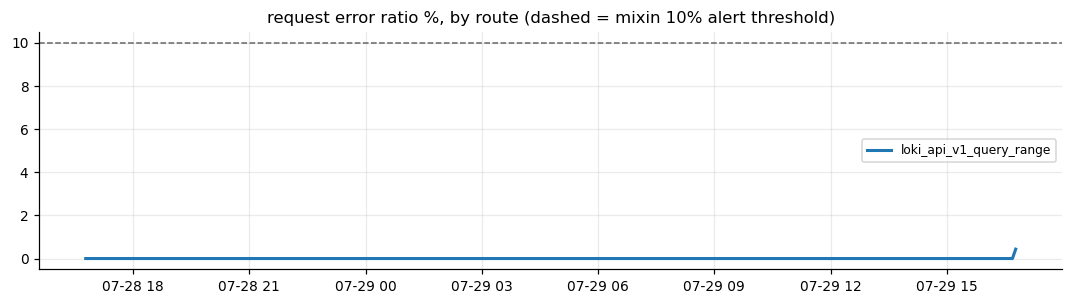

In [6]:
# --- REQUEST ERRORS & PANICS (mixin: LokiRequestErrors >10% 5xx for 15m; LokiRequestPanics >0) ---
err_nz = f_errratio.loc[:, f_errratio.max() > 0] if not f_errratio.empty else f_errratio
err_worst = {c: round(100 * float(err_nz[c].max()), 2) for c in err_nz.columns}
print(f"routes with any 5xx responses in window (max %): {err_worst or 'none'}")
print(f"loki_panic_total increase over {lookback_hours}h: {panics:.0f} (mixin threshold >0)")

fig, ax = plt.subplots(figsize=(12, 2.8))
if err_nz.empty:
    ax.text(0.5, 0.5, 'no request errors in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
else:
    for c in err_nz.columns:
        ax.plot(err_nz.index, 100 * err_nz[c], lw=2, label=c)
    ax.axhline(10, color='0.4', ls='--', lw=1)
    ax.legend(fontsize=8)
ax.set_title('request error ratio %, by route (dashed = mixin 10% alert threshold)')
nbc.show(fig)

ingest: 45.2 lines/s, 25.6 kB/s now (mean 25.5 lines/s over 24h)
active streams in memory: 44
discards by reason (mean/s): none in window


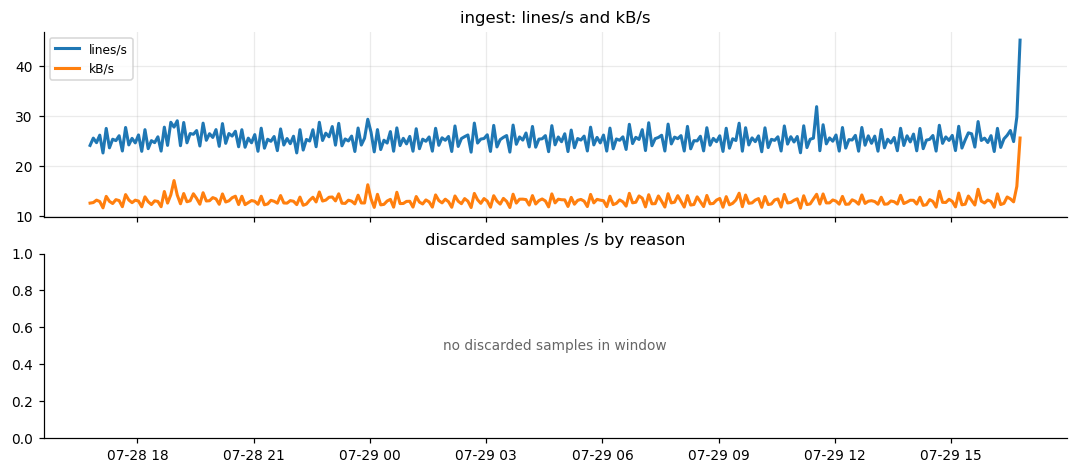

In [7]:
# --- INGEST & STREAMS: lines/s, bytes/s, active streams, discards by reason ---
il = f_ing_lines['value'] if not f_ing_lines.empty else pd.Series(dtype=float)
ib = f_ing_bytes['value'] if not f_ing_bytes.empty else pd.Series(dtype=float)
print(f"ingest: {il.iloc[-1]:,.1f} lines/s, {ib.iloc[-1] / 1e3:,.1f} kB/s now "
      f"(mean {il.mean():,.1f} lines/s over {lookback_hours}h)")
print(f"active streams in memory: {streams_active:,.0f}")
f_discard_nz = f_discard.loc[:, f_discard.max() > 0] if not f_discard.empty else f_discard
discard_mean = {c: round(float(f_discard_nz[c].mean()), 4) for c in f_discard_nz.columns}
print(f"discards by reason (mean/s): {discard_mean or 'none in window'}")

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True)
axes[0].plot(il.index, il, color='C0', lw=2, label='lines/s')
axes[0].plot(ib.index, ib / 1e3, color='C1', lw=2, label='kB/s')
axes[0].legend(fontsize=8)
axes[0].set_title('ingest: lines/s and kB/s')
if f_discard_nz.empty:
    axes[1].text(0.5, 0.5, 'no discarded samples in window', ha='center', va='center',
                 transform=axes[1].transAxes, color='0.4')
    axes[1].grid(False)
else:
    for c in f_discard_nz.columns:
        axes[1].plot(f_discard_nz.index, f_discard_nz[c], lw=2, label=c)
    axes[1].legend(fontsize=8)
axes[1].set_title('discarded samples /s by reason')
nbc.show(fig)

canary entries over 24h: 345,600; missing 0 (0.000%), mismatched 0


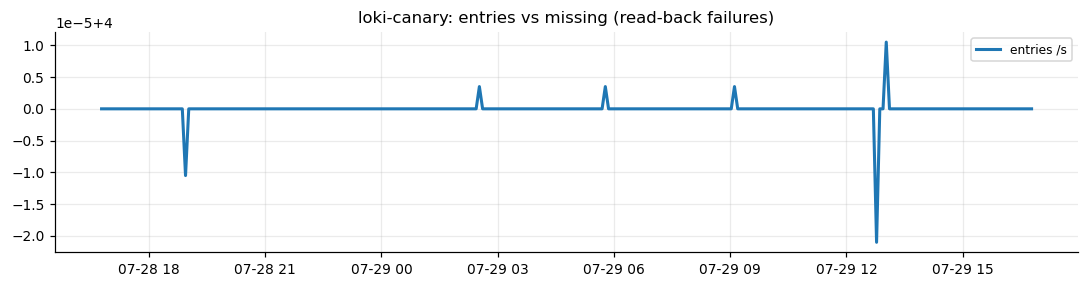

In [8]:
# --- END-TO-END DELIVERY (loki-canary): the sharpest "logs actually flow" check ---
# The canary writes a known stream and reads it back per node. Missing = written but
# unreadable (indexing/query gap); mismatched = corrupted. Either is real data loss.
ce = f_can_entries['value'] if not f_can_entries.empty else pd.Series(dtype=float)
cm = f_can_missing['value'] if not f_can_missing.empty else pd.Series(dtype=float)
loss_pct = 100 * canary_missing_total / canary_entries_total if canary_entries_total else np.nan
print(f"canary entries over {lookback_hours}h: {canary_entries_total:,.0f}; "
      f"missing {canary_missing_total:.0f} ({loss_pct:.3f}%), mismatched {canary_mismatch_total:.0f}")
if np.isinf(inst_age['loki-canary']):
    print("WARNING: canary metrics absent -- this end-to-end check is DARK, not green")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(ce.index, ce, color='C0', lw=2, label='entries /s')
if cm.notna().any() and cm.max() > 0:
    ax.plot(cm.index, cm, color='C3', lw=2, label='missing /s')
ax.legend(fontsize=8)
ax.set_title('loki-canary: entries vs missing (read-back failures)')
nbc.show(fig)

In [9]:
# --- STORAGE: compaction recency (mixin: not-run >3h critical) ---
compactor_age_h = (cap.now - compactor_last) / 3600 if compactor_last else np.inf
print(f"compactor last successful run: "
      f"{'never / no metric' if np.isinf(compactor_age_h) else f'{compactor_age_h:.1f}h ago'}"
      f" (mixin LokiCompactorHasNotSuccessfullyRunCompaction fires at >3h)")

compactor last successful run: 0.2h ago (mixin LokiCompactorHasNotSuccessfullyRunCompaction fires at >3h)


In [10]:
# --- ALERTS (informational): two views of "what is firing" in the loki namespace,
# as a cross-check (Alertmanager API post-routing vs the ALERTS series pre-routing).
# Note: Loki's own mixin rules are not deployed; anything here comes from the
# kubernetes/other mixins that watch the loki namespace generically.
am_rows = [{'alertname': a['labels'].get('alertname', '?'),
            'namespace': a['labels'].get('namespace', ''),
            'state': a.get('status', {}).get('state', '?')}
           for a in am_alerts if a['labels'].get('namespace', '') == namespace]
am_df = pd.DataFrame(am_rows)
print(f"alertmanager: {len(am_df)} active alert instances in namespace '{namespace}' now")
if not am_df.empty:
    print(am_df.groupby(['alertname', 'state']).size().to_string())
metric_now = {r['metric'].get('alertname', '?') for r in alerts_now}
print(f"ALERTS metric firing now in namespace '{namespace}': {sorted(metric_now) or 'none'}")
ns_24h = {r['metric'].get('alertname', '?'): int(float(r['value'][1])) for r in alerts_ns_24h}
print(f"fired in namespace '{namespace}' over trailing 24h: {ns_24h or 'none'}")

alertmanager: 0 active alert instances in namespace 'loki' now
ALERTS metric firing now in namespace 'loki': none
fired in namespace 'loki' over trailing 24h: none


log lines/s by detected_level (mean over 24h): {'error': 0.0, 'info': 8.25, 'unknown': 1.19}


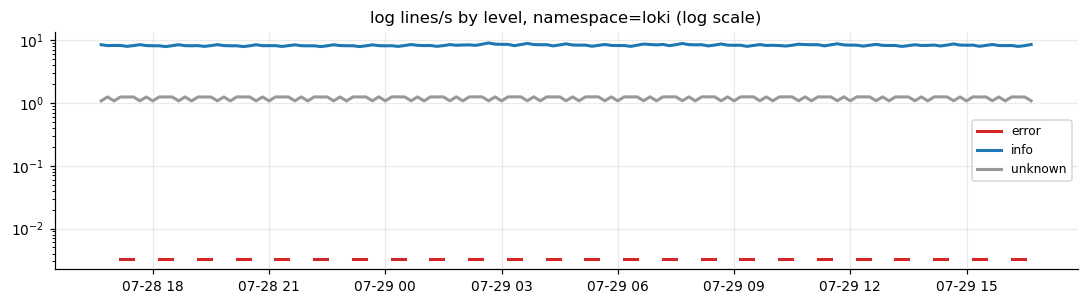

newest error/warn lines (up to 50 in 24h window, newest first):
  29 16:44:02 loki-0                       ts=2026-07-29T16:44:01.988557118Z caller=spanlogger.go:152 middleware=QueryShard.astMapperware org_id=tiles user=tiles level=warn msg="failed mapping 
  29 16:43:57 loki-0                       level=error ts=2026-07-29T16:43:57.867068926Z caller=scheduler_processor.go:172 component=querier org_id=tiles msg="error notifying scheduler about fi
  29 16:43:57 loki-0                       level=error ts=2026-07-29T16:43:57.86528466Z caller=scheduler_processor.go:172 component=querier org_id=tiles msg="error notifying scheduler about fin
  29 16:43:57 loki-0                       level=error ts=2026-07-29T16:43:57.864118289Z caller=scheduler_processor.go:110 component=querier msg="error processing requests from scheduler" err="
  29 16:43:57 loki-0                       level=error ts=2026-07-29T16:43:57.864048925Z caller=scheduler_processor.go:110 component=querier msg="error processi

In [11]:
# --- LOGS (Loki): volume by level, error/warn sample ---
lvl_colors = {'error': 'C3', 'warn': 'C1', 'info': 'C0', 'debug': 'C4', 'unknown': '0.6'}
lvl_rate_mean = {c: round(float(f_loglevel[c].mean() / 600), 2) for c in f_loglevel.columns} if not f_loglevel.empty else {}
print(f"log lines/s by detected_level (mean over {lookback_hours}h): {lvl_rate_mean}")

fig, ax = plt.subplots(figsize=(12, 2.8))
if f_loglevel.empty:
    ax.text(0.5, 0.5, 'no log volume in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
else:
    for c in f_loglevel.columns:
        ax.plot(f_loglevel.index, f_loglevel[c] / 600, lw=2, label=c, color=lvl_colors.get(c, '0.3'))
    ax.legend(fontsize=8)
    ax.set_yscale('log')
ax.set_title(f'log lines/s by level, namespace={namespace} (log scale)')
nbc.show(fig)

errish = sum(f_loglevel.get(lvl, pd.Series(dtype=float)).sum() for lvl in ('error', 'warn'))
if errish > 0 and not log_errwarn:
    print("WARNING: level counts report error/warn lines but the sample query returned "
          "none -- the sample query is broken, do not read this as 'no errors'")
print(f"newest error/warn lines (up to 50 in {lookback_hours}h window, newest first):")
for ts, st, line in log_errwarn[:30]:
    print(f"  {ts:%d %H:%M:%S} {st.get('pod', st.get('detected_level', '?'))[:28]:<28} {line[:150]}")
if len(log_errwarn) > 30:
    print(f"  ... {len(log_errwarn) - 30} more captured (see raw capture)")

In [12]:
# --- LOGS: raw tail sample -- unfiltered cross-check that collection is alive
# and that nothing odd hides below error/warn severity.
print(f"last {len(log_tail)} lines of anything from namespace={namespace}, newest first:")
for ts, st, line in log_tail:
    print(f"  {ts:%H:%M:%S} {st.get('pod', '?')[:28]:<28} {line[:150]}")

last 100 lines of anything from namespace=loki, newest first:
  16:46:30 loki-0                       level=info ts=2026-07-29T16:46:30.404191377Z caller=metrics.go:237 component=frontend org_id=self-monitoring latency=fast query="{stream=\"stdout\",po
  16:46:30 loki-0                       level=info ts=2026-07-29T16:46:30.403385385Z caller=metrics.go:237 component=querier org_id=self-monitoring latency=fast query="{stream=\"stdout\", po
  16:46:30 loki-0                       level=info ts=2026-07-29T16:46:30.402972601Z caller=table_manager.go:195 index-store=tsdb-2024-04-01 msg="get or create table" found=true table=loki_i
  16:46:30 loki-0                       level=info ts=2026-07-29T16:46:30.402393547Z caller=engine.go:274 component=querier org_id=self-monitoring msg="executing query" query="{stream=\"stdo
  16:46:30 loki-0                       level=info ts=2026-07-29T16:46:30.400646479Z caller=metrics.go:409 org_id=self-monitoring latency=fast query_type=stats start=2026-07-

In [13]:
# --- SUMMARY: assumption ledger first, then findings vs explicit thresholds ---
findings = []
if scrape_down:
    findings.append(f"scrape targets down: {scrape_down}")
if oom_pods:
    findings.append(f"last termination OOMKilled: {oom_pods}")
hot = {p: round(v, 0) for p, v in pods['mem_pct'].dropna().items() if v > 90}
if hot:
    findings.append(f"memory >90% of limit: {hot}")
if ring_bad:
    findings.append(f"unhealthy ring members: {ring_bad}")
if compactors_running > 1:
    findings.append(f"more than one compactor running ({compactors_running:.0f}) -- mixin LokiTooManyCompactorsRunning")
sustained_err = {c: round(100 * float(err_nz[c].mean()), 2)
                 for c in err_nz.columns if 100 * err_nz[c].mean() > 10}
if sustained_err:
    findings.append(f"request error ratio >10% mean (mixin threshold): {sustained_err}")
if panics > 0:
    findings.append(f"loki_panic_total increased by {panics:.0f} in window (mixin LokiRequestPanics)")
if canary_missing_total > 0:
    findings.append(f"loki-canary missing entries: {canary_missing_total:.0f} of {canary_entries_total:.0f} "
                    f"({loss_pct:.3f}%) -- reads did not return written logs")
if canary_mismatch_total > 0:
    findings.append(f"loki-canary mismatched entries: {canary_mismatch_total:.0f} -- corruption")
if np.isinf(compactor_age_h):
    findings.append("compactor has no successful-run metric (compaction may never have run)")
elif compactor_age_h > 3:
    findings.append(f"compactor last success {compactor_age_h:.1f}h ago (>3h mixin threshold)")
if ns_24h:
    findings.append(f"alerts fired in namespace {namespace} in 24h: {sorted(ns_24h)}")

print("=" * 60)
print("LOKI HEALTH SUMMARY")
print("=" * 60)
print(f"run:      {cap.run_at}  ({cap.mode})")
print(f"loki:     {loki_version}, tenant {tenant}, lookback {lookback_hours}h")
print()
print("Assumptions: " + ("all instruments fresh" if not assumption_warnings
                         else "; ".join(assumption_warnings)))
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- components up, no request errors/panics, canary clean, "
          "compaction current")
print()
print(f"  Ingest:   {il.mean():,.1f} lines/s mean, {streams_active:,.0f} active streams")
print(f"  Canary:   {canary_entries_total:,.0f} entries, {canary_missing_total:.0f} missing over {lookback_hours}h")
print(f"  Errors:   {err_worst or 'none'}; panics {panics:.0f}")

LOKI HEALTH SUMMARY
run:      2026-07-29T16:46:34.549584+00:00  (live)
loki:     3.6.3, tenant tiles, lookback 24h

Assumptions: all instruments fresh

Findings: none -- components up, no request errors/panics, canary clean, compaction current

  Ingest:   25.5 lines/s mean, 44 active streams
  Canary:   345,600 entries, 0 missing over 24h
  Errors:   {'loki_api_v1_query_range': 0.44}; panics 0


In [14]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads so a reader
# calibrates trust before any verdict.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'loki_version': loki_version,
    'lookback_hours': lookback_hours,
    'assumptions': {
        'status': 'ok' if not assumption_warnings else 'degraded',
        'warnings': assumption_warnings,
        'instrument_age_s': {k: _n(v) for k, v in inst_age.items()},
    },
    'findings': findings,
    'components': {
        'scrape_down': scrape_down,
        'restarts_by_pod': restart_pods,
        'oom_last_term': oom_pods,
        'mem_pct_of_limit': {p: _n(v) for p, v in pods['mem_pct'].dropna().items()},
        'ring_unhealthy': ring_bad,
        'compactors_running': _n(compactors_running),
    },
    'request_errors': {'max_pct_by_route': err_worst, 'panics_in_window': _n(panics)},
    'ingest': {'lines_per_s_mean': _n(il.mean()), 'active_streams': _n(streams_active),
               'discarded_per_s_mean_by_reason': discard_mean},
    'canary': {'entries': _n(canary_entries_total), 'missing': _n(canary_missing_total),
               'mismatched': _n(canary_mismatch_total), 'loss_pct': _n(loss_pct)},
    'storage': {'compactor_last_success_age_h': _n(compactor_age_h)},
    'alerts': {'active_now': sorted({r['alertname'] for r in am_rows}),
               'metric_firing_now': sorted(metric_now), 'namespace_24h': ns_24h},
    'logs': {
        'lines_per_s_mean_by_level': lvl_rate_mean,
        'errwarn_captured': len(log_errwarn),
        'errwarn_newest': [f"{ts:%Y-%m-%d %H:%M:%S} {st.get('pod', '?')} {line[:150]}"
                           for ts, st, line in log_errwarn[:10]],
    },
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "loki-health.ipynb",
 "run_at": "2026-07-29T16:46:34.549584+00:00",
 "mode": "live",
 "loki_version": "3.6.3",
 "lookback_hours": 24,
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "loki self-monitoring": 13.4326,
   "loki-canary": 1.4216,
   "kube-state-metrics (loki ns)": 57.1326,
   "cadvisor (loki ns)": 17.6536,
   "loki (loki ns logs)": 4.0664
  }
 },
 "findings": [],
 "components": {
  "scrape_down": [],
  "restarts_by_pod": {
   "loki-0": 5,
   "loki-canary-clnfq": 1
  },
  "oom_last_term": [],
  "mem_pct_of_limit": {},
  "ring_unhealthy": {},
  "compactors_running": 1.0
 },
 "request_errors": {
  "max_pct_by_route": {
   "loki_api_v1_query_range": 0.44
  },
  "panics_in_window": 0.0
 },
 "ingest": {
  "lines_per_s_mean": 25.4725,
  "active_streams": 44.0,
  "discarded_per_s_mean_by_reason": {}
 },
 "canary": {
  "entries": 345600.0,
  "missing": 0.0,
  "mismatched": 0.0,
  "loss_pct": 0.0
 },
 "storage": {
  "compactor_last_succe